<a href="https://colab.research.google.com/github/springboardmentor14065l/Smart-Energy-Consumption-Analysis-and-Prediction-using-Machine-Learning-with-Device-Level-Insights/blob/Nikhil-yadav/week%201-2/Data_Collection_and_Understanding_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
"""
Project Scope & Functional Objectives
📌 Project Scope

The project focuses on analyzing and predicting household energy consumption using smart meter data with device-level insights.

🎯 Functional Objectives

Monitor energy usage per appliance

Identify high-consumption devices

Analyze time-based usage patterns

Predict future energy consumption using ML

Support energy optimization & cost reduction"""

'\nProject Scope & Functional Objectives\n📌 Project Scope\n\nThe project focuses on analyzing and predicting household energy consumption using smart meter data with device-level insights.\n\n🎯 Functional Objectives\n\nMonitor energy usage per appliance\n\nIdentify high-consumption devices\n\nAnalyze time-based usage patterns\n\nPredict future energy consumption using ML\n\nSupport energy optimization & cost reduction'

In [ ]:
"""
Data Collection & Dataset Structure
📌 Dataset Description

The SmartHome Energy Monitoring Dataset contains:

Timestamped energy readings

Device-level consumption

Environmental and household context

📊 Key Attributes
Column	Description
Timestamp / Year, Month, Day, Hour	Time of reading
Home ID	Unique household
Appliance Type	Device name
Energy Consumption (kWh)	Target variable
Outdoor Temperature (°C)	Environmental factor
Season	Seasonal context
Household Size	Occupancy information"""

In [1]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/energy.csv")
df['Timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['Minute'] = df['Timestamp'].dt.minute
df = df.drop(['Date', 'Time'], axis=1)
cols = ['Timestamp'] + [c for c in df.columns if c != 'Timestamp']
df = df[cols]
df.to_csv("energy_data_with_timestamp.csv", index=False)
df.head()

,Timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Year,Month,Day,Hour,Minute
0,2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2,2023,12,2,21,12
1,2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5,2023,8,6,20,11
2,2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3,2023,11,21,6,39
3,2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1,2023,1,21,21,56
4,2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5,2023,8,26,4,31


In [2]:
df = pd.read_csv("energy_data_with_timestamp.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.set_index('Timestamp')
df

,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Year,Month,Day,Hour,Minute
Timestamp,,,,,,,,,,,
2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2,2023,12,2,21,12
2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5,2023,8,6,20,11
2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3,2023,11,21,6,39
2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1,2023,1,21,21,56
2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5,2023,8,26,4,31
...,...,...,...,...,...,...,...,...,...,...,...
2023-09-28 09:56:00,124,Microwave,0.42,20.5,Summer,1,2023,9,28,9,56
2023-05-27 12:48:00,184,Computer,0.71,-5.4,Spring,2,2023,5,27,12,48
2023-02-18 05:45:00,101,Dishwasher,0.25,35.6,Winter,3,2023,2,18,5,45


In [3]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [4]:
df.head()



,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,Year,Month,Day,Hour,Minute
Timestamp,,,,,,,,,,,
2023-12-02 21:12:00,94,Fridge,0.20,-1.0,Fall,2,2023,12,2,21,12
2023-08-06 20:11:00,435,Oven,0.23,31.1,Summer,5,2023,8,6,20,11
2023-11-21 06:39:00,466,Dishwasher,0.32,21.3,Fall,3,2023,11,21,6,39
2023-01-21 21:56:00,496,Heater,3.92,-4.2,Winter,1,2023,1,21,21,56
2023-08-26 04:31:00,137,Microwave,0.44,34.5,Summer,5,2023,8,26,4,31


In [5]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/energy.csv")

In [ ]:
print(df.columns)


Index(['Home ID', 'Appliance Type', 'Energy Consumption (kWh)', 'Time', 'Date',
       'Outdoor Temperature (°C)', 'Season', 'Household Size'],
      dtype='object')


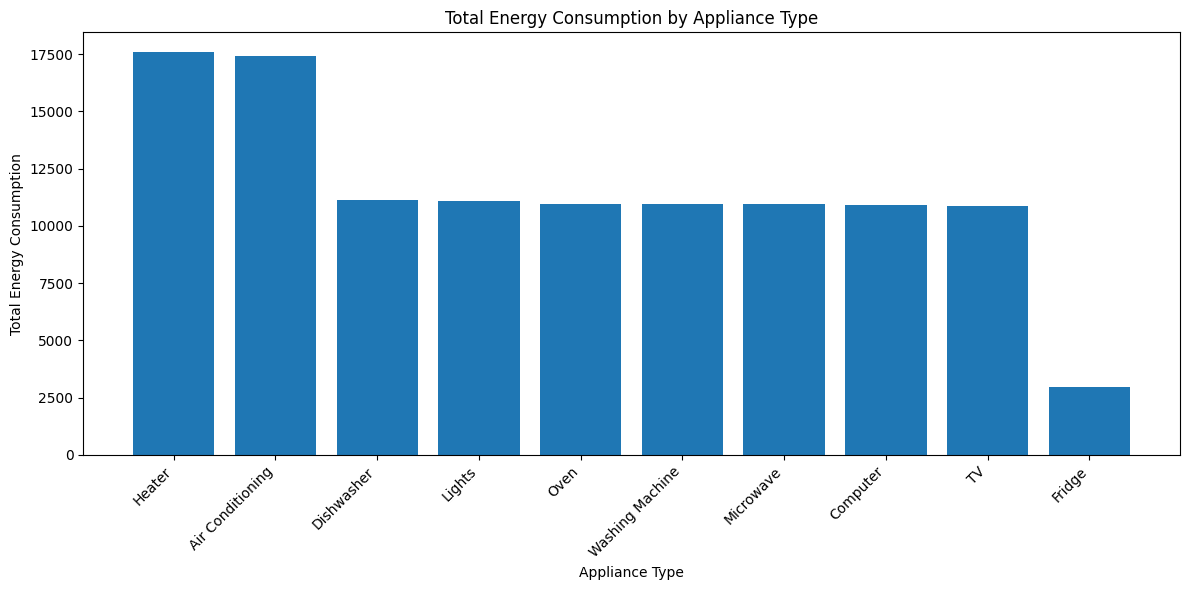

In [13]:
import matplotlib.pyplot as plt

# Group by appliance type and sum energy consumption
energy_by_appliance = (
    df.groupby('Appliance Type')['Energy Consumption (kWh)']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(energy_by_appliance.index, energy_by_appliance.values)
plt.title('Total Energy Consumption by Appliance Type')
plt.xlabel('Appliance Type')
plt.ylabel('Total Energy Consumption')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
